In [ ]:
from torchvision import datasets, transforms
import torch
import kagglehub
import os
from torch.utils.data import DataLoader, random_split
import pandas as pd

import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
from torch.utils.data import random_split, Subset
from torchvision import models

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
results_path = '/content/drive/MyDrive/UPF_Deep_Learning_2026/Final_Project/results/'

os.makedirs(results_path, exist_ok=True)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Using device: {device}")

Using device: cuda


LOAD THE DATASET

In [ ]:
path = kagglehub.dataset_download("andradaolteanu/gtzan-dataset-music-genre-classification")
print(os.listdir(path))

100%|██████████| 1.21G/1.21G [00:14<00:00, 91.7MB/s]

Extracting files...


['Data']


In [ ]:
images_path = os.path.join(path, "Data/images_original")
csv_path    = f"{path}/Data/features_30_sec.csv"

In [ ]:
df = pd.read_csv(csv_path)
df = df.drop(columns=['filename', 'length']) #no needed

MLP (features)

In [ ]:
# Drop no util columns
X = df.drop(columns=['label'])
y = df['label']

# Codify labels with numbers
encoder = LabelEncoder()
y = encoder.fit_transform(y)

# Split train / val / test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

# Normalize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Tensors
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
X_val = torch.tensor(X_val, dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)

y_train = torch.tensor(y_train, dtype=torch.long).to(device) #long to use CrossEntropy()
y_val = torch.tensor(y_val, dtype=torch.long).to(device)
y_test = torch.tensor(y_test, dtype=torch.long).to(device)

# Dataloaders
batch_size = 32
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False)

MLP ARCHITECTURE

In [ ]:
class MLP_PyTorch(nn.Module):
    """
    Multilayer Perceptron

    Attributes:
        Linear1 (nn.Linear): First linear layer (input → hidden1)
        Linear2 (nn.Linear): Second linear layer (hidden1 → hidden2)
        Linear3 (nn.Linear): Third linear layer (hidden2 → output)
        relu (nn.ReLU): ReLU activation function
        dropout (nn.Dropout): Dropout to prevent overfitting
    """
    def __init__(self, inputNode: int = 57,
                       hiddenNode1: int = 256,
                       hiddenNode2: int = 128,
                       outputNode: int = 10) -> None:
        """
        Parameters:
            inputNode  (int): input features (57)
            hiddenNode1(int): Neurons in the first layer
            hiddenNode2(int): Neurons in the second layer
            outputNode (int): Classifier (10)
        """
        super(MLP_PyTorch, self).__init__()

        self.Linear1 = nn.Linear(inputNode, hiddenNode1)
        self.Linear2 = nn.Linear(hiddenNode1, hiddenNode2)
        self.Linear3 = nn.Linear(hiddenNode2, outputNode)
        self.relu    = nn.ReLU()
        # Dropout: apaga el 30% de neuronas aleatoriamente
        # para evitar que el modelo memorice los datos
        self.dropout = nn.Dropout(0.3)

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        """
        Defines the forward pass of the model.

        Parameters:
            X (torch.Tensor): Input tensor.

        Returns:
            torch.Tensor: The output of the model. (batch, 10)
            *CrossEntropy applies Softmax internally
        """
        out = self.Linear1(X)      # (batch, 57)  → (batch, 256)
        out = self.relu(out)       # no lineal activation
        out = self.dropout(out)
        out = self.Linear2(out)    # (batch, 256) → (batch, 128)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.Linear3(out)    # (batch, 128) → (batch, 10)
        return out

In [ ]:
def train_and_validate_torch(NN, X_train, y_train, X_test, y_test,
                              epoch=100, optim=None, step=10):

    """
    Trains the MLP using the specified optimizer and parameters.

    Parameters:
        NN (MLP_PyTorch): The MLP model to train.
        X (torch.Tensor): Input features.
        y (torch.Tensor): Target output labels.
        epoch (int): Number of training iterations.
        lr (float): Learning rate for the optimizer.
        optimizer (torch.optim.Optimizer): Optimizer for updating model weights.

    Returns:
        list: A list of loss values recorded throughout the training process.
    """

    list_loss_train = []
    list_loss_val = []
    list_accs_train = []
    list_accs_val = []
    loss_function = nn.CrossEntropyLoss()

    for i in tqdm(range(epoch)):
        #  TRAIN
        NN.train()

        optim.zero_grad()
        y_hat_train = NN(X_train)                    # logits, shape: (N, num_classes)
        loss_train = loss_function(y_hat_train, y_train)
        loss_train.backward()
        optim.step()

        # Accuracy train
        preds_train = torch.argmax(y_hat_train, dim=1)
        acc_train = (preds_train == y_train).float().mean().item()

        #  VALIDATION
        if i % step == 0:
            NN.eval()
            with torch.no_grad():
                y_hat_val = NN(X_val)
                loss_val = loss_function(y_hat_val, y_val)

                preds_val = torch.argmax(y_hat_val, dim=1)
                acc_val = (preds_val == y_val).float().mean().item()

            list_loss_train.append(loss_train.item())
            list_loss_val.append(loss_val.item())
            list_accs_train.append(acc_train)
            list_accs_val.append(acc_val)

            print(
                f"Epoch {i:4d} | "
                f"Train Loss: {loss_train.item():.4f} | Train Acc: {acc_train:.4f} | "
                f"Val Loss: {loss_val.item():.4f} | Val Acc: {acc_val:.4f}"
            )

    return list_loss_train, list_loss_val, list_accs_train, list_accs_val

MLP TRAINING (3s and 3s)

100%|██████████| 100/100 [00:00<00:00, 120.14it/s]

Epoch    0 | Train Loss: 2.3080 | Train Acc: 0.1163 | Val Loss: 2.2360 | Val Acc: 0.2800
Epoch   10 | Train Loss: 1.8156 | Train Acc: 0.3950 | Val Loss: 1.7574 | Val Acc: 0.3900
Epoch   20 | Train Loss: 1.4135 | Train Acc: 0.4950 | Val Loss: 1.4106 | Val Acc: 0.4600
Epoch   30 | Train Loss: 1.1762 | Train Acc: 0.5900 | Val Loss: 1.2111 | Val Acc: 0.5300
Epoch   40 | Train Loss: 0.9782 | Train Acc: 0.6650 | Val Loss: 1.0743 | Val Acc: 0.6600
Epoch   50 | Train Loss: 0.8281 | Train Acc: 0.7138 | Val Loss: 0.9452 | Val Acc: 0.7100
Epoch   60 | Train Loss: 0.7081 | Train Acc: 0.7587 | Val Loss: 0.8759 | Val Acc: 0.7500
Epoch   70 | Train Loss: 0.6282 | Train Acc: 0.7925 | Val Loss: 0.8276 | Val Acc: 0.8000
Epoch   80 | Train Loss: 0.5592 | Train Acc: 0.8050 | Val Loss: 0.7892 | Val Acc: 0.8300
Epoch   90 | Train Loss: 0.4814 | Train Acc: 0.8388 | Val Loss: 0.7736 | Val Acc: 0.8100


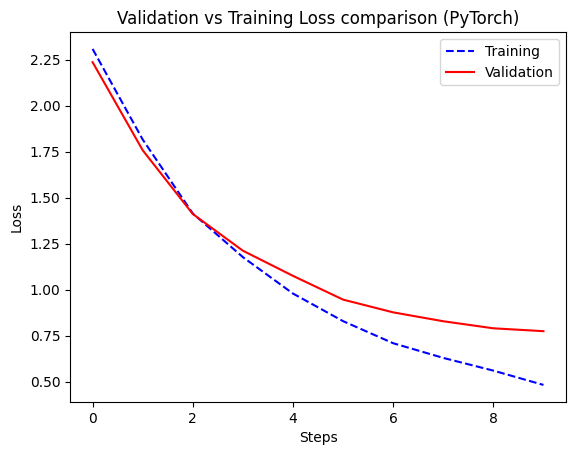

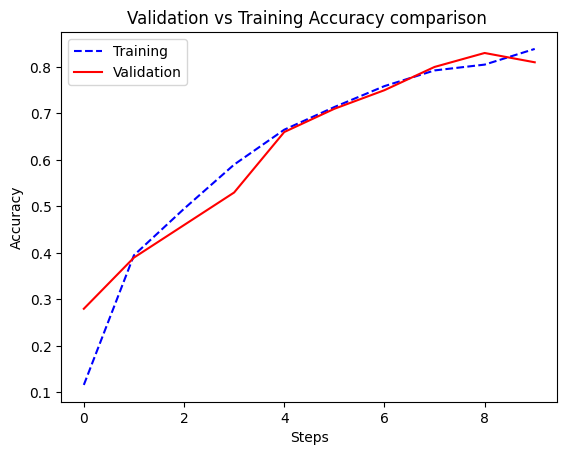

In [ ]:
# Initialize the PyTorch MLP model and optimizer
NN = MLP_PyTorch(
    inputNode=X_train.shape[1],
    hiddenNode1=256,
    hiddenNode2=128,
    outputNode=len(encoder.classes_)
).to(device)

optimizer = optim.Adam(NN.parameters(), lr=1e-3)

# Train the MLP using PyTorch
list_loss_train, list_loss_val, list_acc_train, list_acc_val = train_and_validate_torch(NN, X_train, y_train, X_test, y_test, optim=optimizer, epoch= 100)


# Plot a figure showing the training loss and validation loss together. This will be your baseline performance plot.
plt.plot(list_loss_train, 'b--', label='Training')
plt.plot(list_loss_val, 'r-', label='Validation')
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Validation vs Training Loss comparison (PyTorch)")
plt.legend()
plt.show()

# Plot
plt.plot(list_acc_train, 'b--', label='Training')
plt.plot(list_acc_val,   'r-',  label='Validation')
plt.xlabel("Steps")
plt.ylabel("Accuracy")
plt.title("Validation vs Training Accuracy comparison ")
plt.legend()
plt.show()

CONFUSION MATRIX

In [ ]:
def evaluate_model_torch(NN, X_test, y_test, encoder):
    """
    Evaluates the trained MLP on the test set and plots the confusion matrix.

    Parameters:
        NN (MLP_PyTorch): Trained model.
        X_test (torch.Tensor): Test features.
        y_test (torch.Tensor): True test labels.
        encoder (LabelEncoder): Encoder used to transform genre labels.

    Returns:
        acc_test (float): Test accuracy.
        cm (np.ndarray): Confusion matrix.
        y_pred (np.ndarray): Predicted labels.
    """

    NN.eval()

    with torch.no_grad():
        y_hat_test = NN(X_test)                       # logits
        preds_test = torch.argmax(y_hat_test, dim=1) # predicted classes

    y_true = y_test.cpu().numpy()
    y_pred = preds_test.cpu().numpy()

    acc_test = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print(f"Test Accuracy: {acc_test:.4f}")
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=encoder.classes_))

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=encoder.classes_,
        yticklabels=encoder.classes_
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title("Confusion Matrix - MLP PyTorch")
    plt.tight_layout()
    plt.show()

    return acc_test, cm, y_pred

Test Accuracy: 0.7000

Classification Report:

              precision    recall  f1-score   support

       blues       0.64      0.90      0.75        10
   classical       0.90      0.90      0.90        10
     country       0.80      0.80      0.80        10
       disco       0.50      0.40      0.44        10
      hiphop       0.64      0.70      0.67        10
        jazz       0.80      0.80      0.80        10
       metal       1.00      0.70      0.82        10
         pop       0.58      0.70      0.64        10
      reggae       0.60      0.60      0.60        10
        rock       0.62      0.50      0.56        10

    accuracy                           0.70       100
   macro avg       0.71      0.70      0.70       100
weighted avg       0.71      0.70      0.70       100



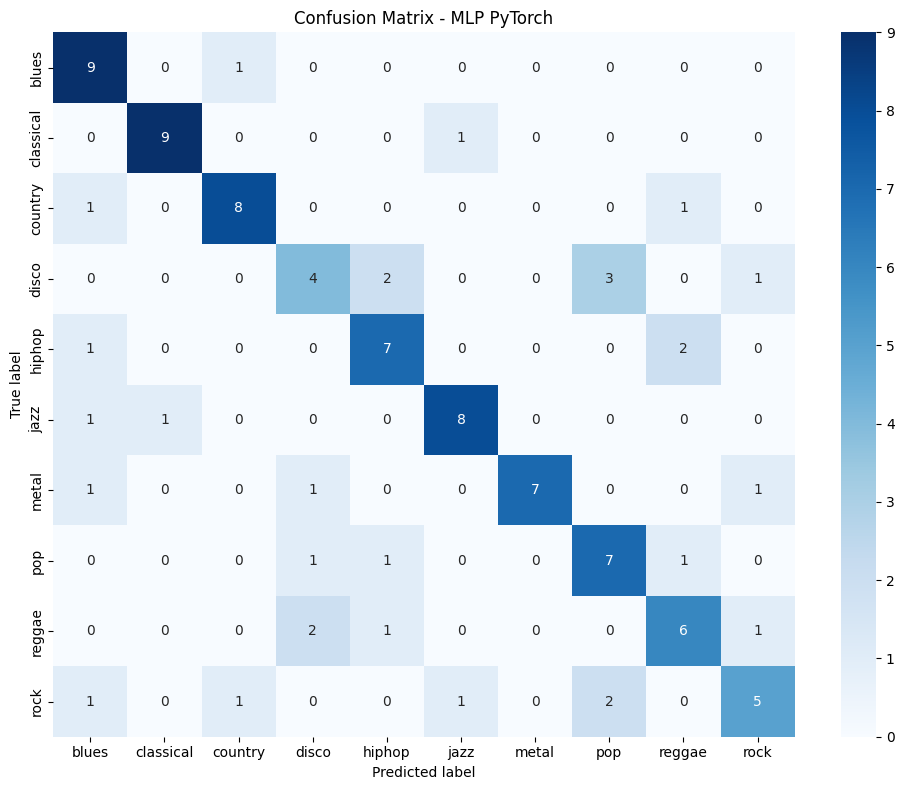

In [ ]:
acc_test, cm, y_pred = evaluate_model_torch(NN, X_test, y_test, encoder)

K-FOLD


FOLD 1/5


  7%|▋         | 7/100 [00:00<00:03, 25.26it/s]

Epoch    0 | Train Loss: 2.3182 | Train Acc: 0.0850 | Val Loss: 2.2647 | Val Acc: 0.2200


100%|██████████| 100/100 [00:03<00:00, 26.01it/s]


Test Accuracy: 0.7400

Classification Report:

              precision    recall  f1-score   support

       blues       0.94      0.80      0.86        20
   classical       0.89      0.85      0.87        20
     country       0.76      0.80      0.78        20
       disco       0.62      0.50      0.56        20
      hiphop       0.77      0.85      0.81        20
        jazz       0.71      0.75      0.73        20
       metal       0.93      0.65      0.76        20
         pop       0.63      0.85      0.72        20
      reggae       0.76      0.80      0.78        20
        rock       0.50      0.55      0.52        20

    accuracy                           0.74       200
   macro avg       0.75      0.74      0.74       200
weighted avg       0.75      0.74      0.74       200



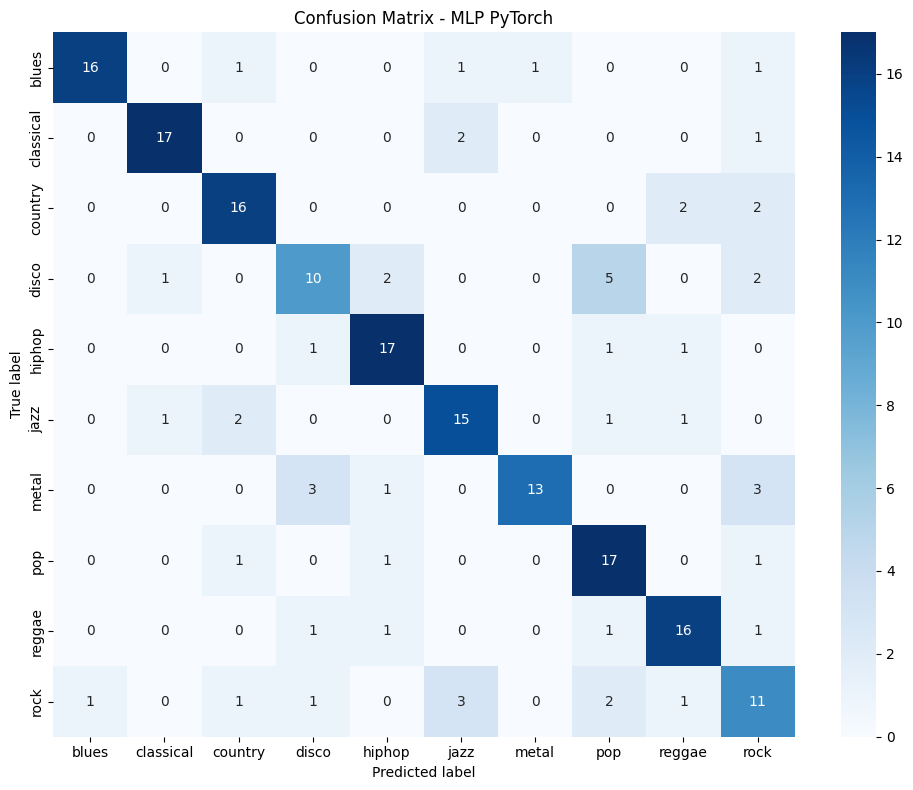

Fold 1 Accuracy: 0.7400

FOLD 2/5


  3%|▎         | 3/100 [00:00<00:03, 26.30it/s]

Epoch    0 | Train Loss: 2.3018 | Train Acc: 0.1000 | Val Loss: 2.2370 | Val Acc: 0.2500


100%|██████████| 100/100 [00:02<00:00, 41.26it/s]


Test Accuracy: 0.7300

Classification Report:

              precision    recall  f1-score   support

       blues       0.65      0.85      0.74        20
   classical       1.00      0.95      0.97        20
     country       0.78      0.70      0.74        20
       disco       0.52      0.60      0.56        20
      hiphop       0.69      0.55      0.61        20
        jazz       0.94      0.80      0.86        20
       metal       0.82      0.90      0.86        20
         pop       0.79      0.75      0.77        20
      reggae       0.62      0.65      0.63        20
        rock       0.58      0.55      0.56        20

    accuracy                           0.73       200
   macro avg       0.74      0.73      0.73       200
weighted avg       0.74      0.73      0.73       200



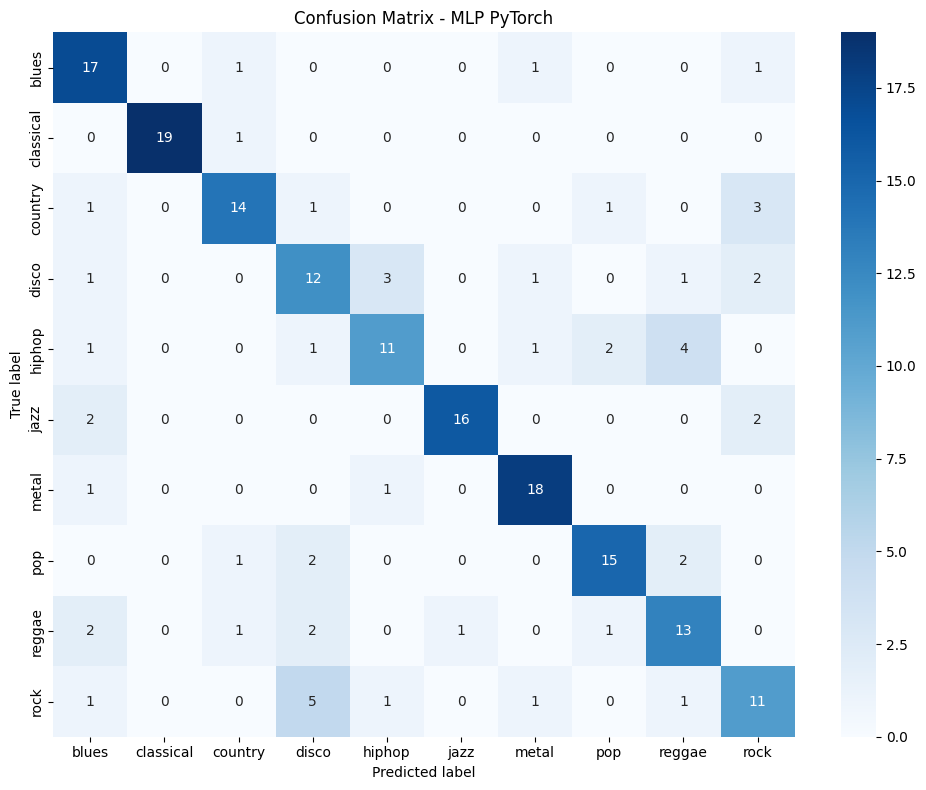

Fold 2 Accuracy: 0.7300

FOLD 3/5


  6%|▌         | 6/100 [00:00<00:02, 42.71it/s]

Epoch    0 | Train Loss: 2.3301 | Train Acc: 0.0562 | Val Loss: 2.2700 | Val Acc: 0.1800


100%|██████████| 100/100 [00:02<00:00, 42.91it/s]


Test Accuracy: 0.7300

Classification Report:

              precision    recall  f1-score   support

       blues       0.80      0.40      0.53        20
   classical       0.80      1.00      0.89        20
     country       0.58      0.70      0.64        20
       disco       0.72      0.65      0.68        20
      hiphop       0.81      0.85      0.83        20
        jazz       0.69      0.90      0.78        20
       metal       0.74      0.85      0.79        20
         pop       0.73      0.80      0.76        20
      reggae       0.74      0.70      0.72        20
        rock       0.75      0.45      0.56        20

    accuracy                           0.73       200
   macro avg       0.74      0.73      0.72       200
weighted avg       0.74      0.73      0.72       200



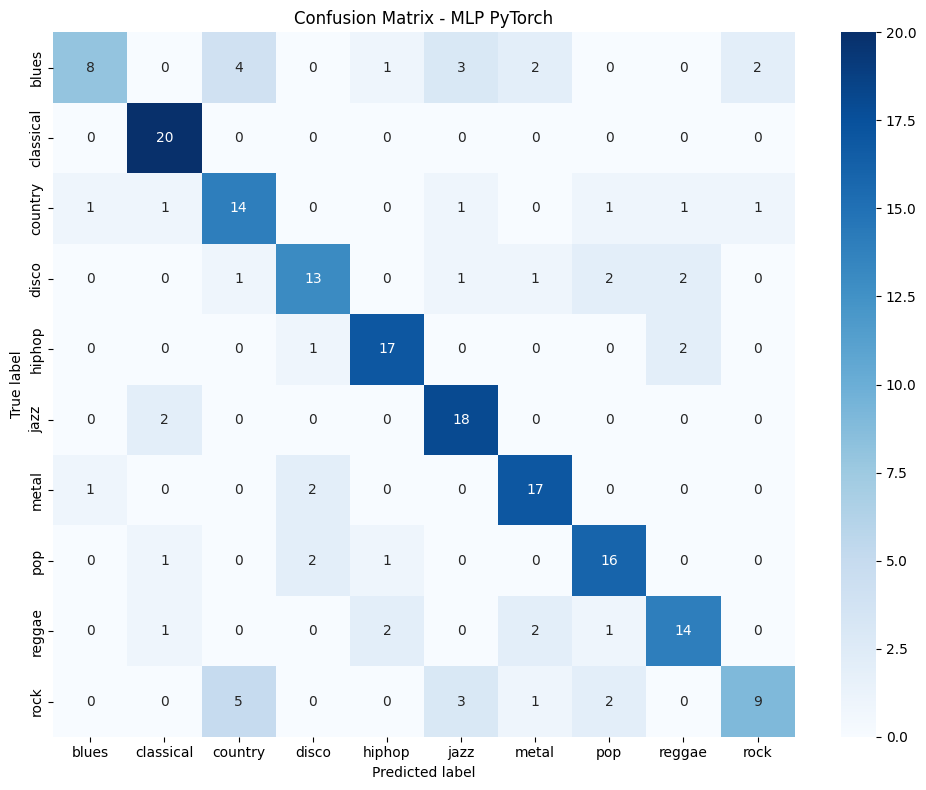

Fold 3 Accuracy: 0.7300

FOLD 4/5


  2%|▏         | 2/100 [00:00<00:05, 18.98it/s]

Epoch    0 | Train Loss: 2.3033 | Train Acc: 0.1112 | Val Loss: 2.2420 | Val Acc: 0.2200


100%|██████████| 100/100 [00:02<00:00, 34.70it/s]


Test Accuracy: 0.7700

Classification Report:

              precision    recall  f1-score   support

       blues       0.85      0.85      0.85        20
   classical       0.89      0.85      0.87        20
     country       0.85      0.85      0.85        20
       disco       0.67      0.50      0.57        20
      hiphop       0.72      0.65      0.68        20
        jazz       0.86      0.95      0.90        20
       metal       0.81      0.85      0.83        20
         pop       0.80      0.80      0.80        20
      reggae       0.68      0.65      0.67        20
        rock       0.58      0.75      0.65        20

    accuracy                           0.77       200
   macro avg       0.77      0.77      0.77       200
weighted avg       0.77      0.77      0.77       200



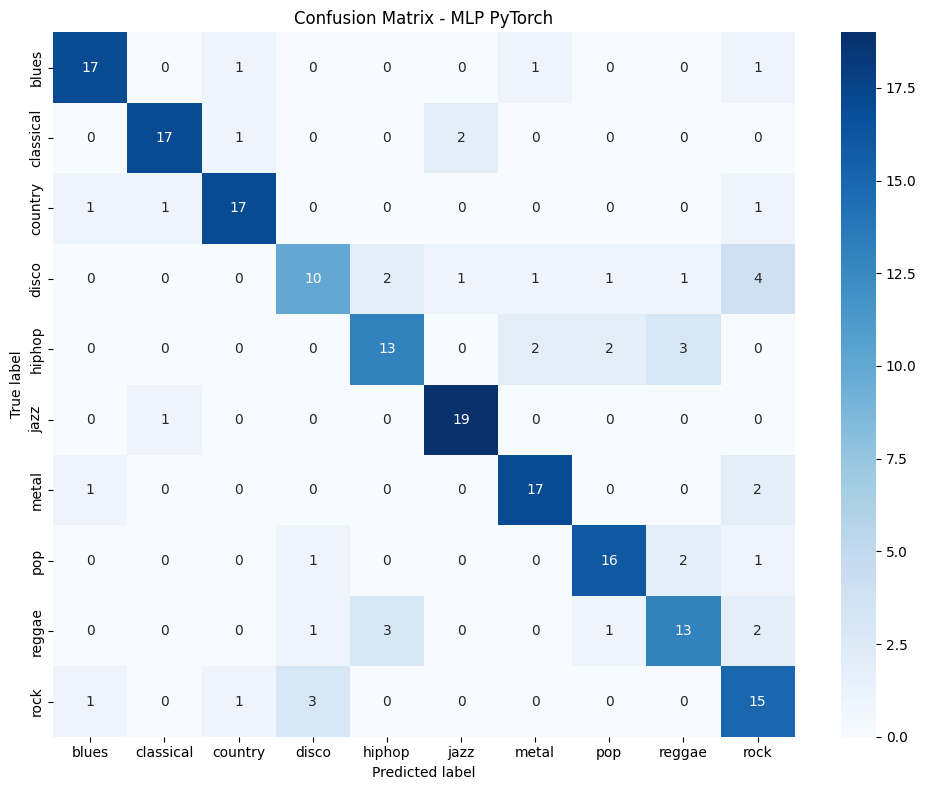

Fold 4 Accuracy: 0.7700

FOLD 5/5


  5%|▌         | 5/100 [00:00<00:02, 47.03it/s]

Epoch    0 | Train Loss: 2.3060 | Train Acc: 0.1312 | Val Loss: 2.2434 | Val Acc: 0.2300


100%|██████████| 100/100 [00:01<00:00, 53.51it/s]


Test Accuracy: 0.7100

Classification Report:

              precision    recall  f1-score   support

       blues       0.57      0.80      0.67        20
   classical       0.95      1.00      0.98        20
     country       0.90      0.45      0.60        20
       disco       0.59      0.65      0.62        20
      hiphop       0.86      0.60      0.71        20
        jazz       0.90      0.90      0.90        20
       metal       0.79      0.95      0.86        20
         pop       0.71      0.75      0.73        20
      reggae       0.50      0.60      0.55        20
        rock       0.50      0.40      0.44        20

    accuracy                           0.71       200
   macro avg       0.73      0.71      0.71       200
weighted avg       0.73      0.71      0.71       200



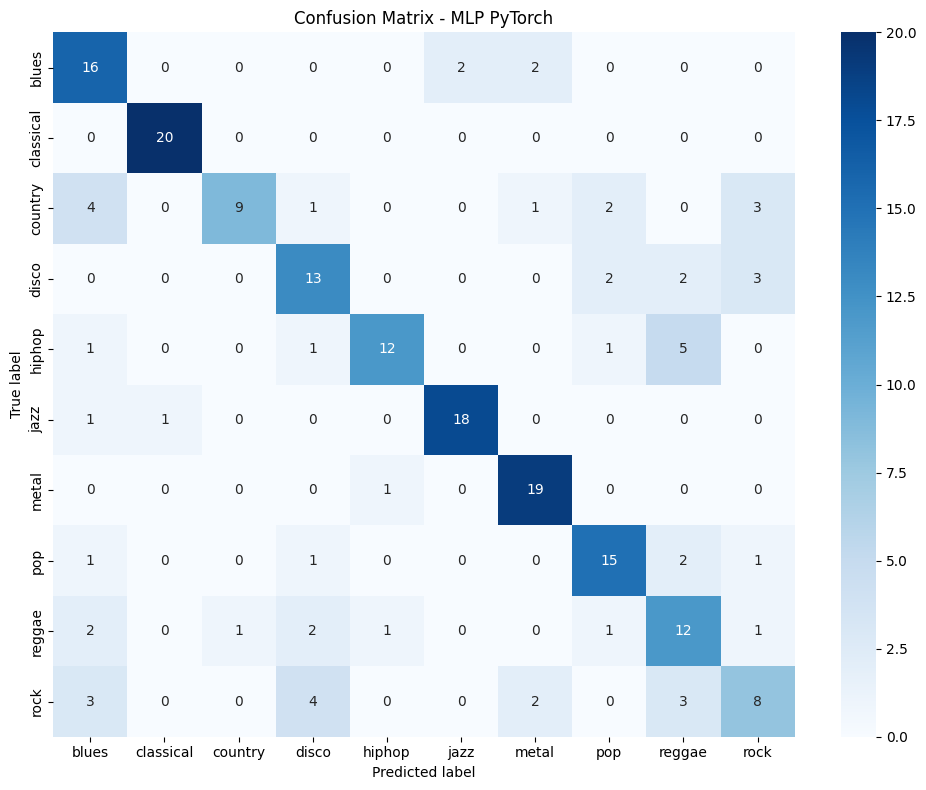

Fold 5 Accuracy: 0.7100

RESULTS K-FOLD (5 folds)
  Fold 1: 0.7400
  Fold 2: 0.7300
  Fold 3: 0.7300
  Fold 4: 0.7700
  Fold 5: 0.7100

Mean:          0.7360
Std: 0.0196

Final result: 0.7360 ± 0.0196


In [ ]:
#K-FOLDS
from sklearn.model_selection import StratifiedKFold

X_np = df.drop(columns=['label']).values  # numpy array
y_np = encoder.fit_transform(df['label']) # numpy array

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) ## StratifiedKFold mantains same genre proportion

fold_accuracies = []  #save accuracy of each fold

for fold, (train_idx, test_idx) in enumerate(kf.split(X_np, y_np)):
    print(f"\n{'='*50}")
    print(f"FOLD {fold+1}/5")
    print(f"{'='*50}")

    X_train_f, X_test_f = X_np[train_idx], X_np[test_idx]
    y_train_f, y_test_f = y_np[train_idx], y_np[test_idx]

    # Normalize
    scaler_f = StandardScaler()
    X_train_f = scaler_f.fit_transform(X_train_f)
    X_test_f  = scaler_f.transform(X_test_f)

    # Tensors
    X_train_t = torch.tensor(X_train_f, dtype=torch.float32).to(device)
    X_test_t  = torch.tensor(X_test_f,  dtype=torch.float32).to(device)
    y_train_t = torch.tensor(y_train_f, dtype=torch.long).to(device)
    y_test_t  = torch.tensor(y_test_f,  dtype=torch.long).to(device)

    # Creat new model for each fold
    model_fold = MLP_PyTorch(
        inputNode  = X_train_t.shape[1],
        hiddenNode1= 256,
        hiddenNode2= 128,
        outputNode = len(encoder.classes_)
    ).to(device)

    optimizer_fold = optim.Adam(model_fold.parameters(), lr=1e-3)

    train_and_validate_torch(
        model_fold,
        X_train_t, y_train_t,
        X_test_t,  y_test_t,
        epoch=100,
        optim=optimizer_fold,
        step=100
    )

    acc, cm, y_pred = evaluate_model_torch(
        model_fold, X_test_t, y_test_t, encoder
    )
    fold_accuracies.append(acc)
    print(f"Fold {fold+1} Accuracy: {acc:.4f}")

# Final result
print(f"\n{'='*50}")
print(f"RESULTS K-FOLD (5 folds)")
print(f"{'='*50}")
for i, acc in enumerate(fold_accuracies):
    print(f"  Fold {i+1}: {acc:.4f}")
print(f"\nMean:          {np.mean(fold_accuracies):.4f}")
print(f"Std: {np.std(fold_accuracies):.4f}")
print(f"\nFinal result: {np.mean(fold_accuracies):.4f} ± {np.std(fold_accuracies):.4f}")

CNN (data extraction)


In [ ]:
base_dataset = datasets.ImageFolder(root=images_path, transform=None)

# 2) Split indices
n_total = len(base_dataset)
n_train = int(0.8 * n_total)
n_val = int(0.1 * n_total)
n_test = n_total - n_train - n_val

train_idx, val_idx, test_idx = random_split(range(n_total),[n_train, n_val, n_test],generator=torch.Generator().manual_seed(42))

train_idx = train_idx.indices
val_idx = val_idx.indices
test_idx = test_idx.indices

resnet_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

resnet_eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

eval_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])
train_full = datasets.ImageFolder(root=images_path, transform=train_transform)
val_full   = datasets.ImageFolder(root=images_path, transform=eval_transform)
test_full  = datasets.ImageFolder(root=images_path, transform=eval_transform)

resnet_train_full = datasets.ImageFolder(root=images_path, transform=resnet_train_transform)
resnet_val_full   = datasets.ImageFolder(root=images_path, transform=resnet_eval_transform)
resnet_test_full  = datasets.ImageFolder(root=images_path, transform=resnet_eval_transform)


train_dataset = Subset(train_full, train_idx)
val_dataset   = Subset(val_full,   val_idx)
test_dataset  = Subset(test_full,  test_idx)

resnet_train_dataset = Subset(resnet_train_full, train_idx)
resnet_val_dataset   = Subset(resnet_val_full,   val_idx)
resnet_test_dataset  = Subset(resnet_test_full,  test_idx)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

resnet_train_loader = DataLoader(resnet_train_dataset, batch_size=32, shuffle=True)
resnet_val_loader = DataLoader(resnet_val_dataset, batch_size=32, shuffle=False)
resnet_test_loader = DataLoader(resnet_test_dataset, batch_size=32, shuffle=False)

CNN (architecture)

In [ ]:
class CNNGenre(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

CNN TRAINING

In [ ]:
from typing import Tuple, List
import time
import torch
import torch.nn as nn
import torch.optim as optim

def train_step(model: nn.Module,
               dataloader: torch.utils.data.DataLoader,
               criterion: nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device) -> Tuple[float, float]:
    """
    Executes one full training epoch on the given dataloader.

    Args:
        model (nn.Module): The CNN model to train.
        dataloader (torch.utils.data.DataLoader): The DataLoader for the training dataset.
        criterion (nn.Module): Loss function used to compute training loss.
        optimizer (torch.optim.Optimizer): Optimizer used for weight updates.
        device (torch.device): Device to perform computation ('cuda' or 'cpu').

    Returns:
        Tuple[float, float]: Average training loss and training accuracy for the epoch.
    """
    model.train()  # Set model to training mode
    model.to(device)  # Move model to the computation device
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)  # Move inputs to the computation device
        labels = labels.type(torch.LongTensor).to(device)  # Convert labels and move to device

        outputs = model(images)  # Forward pass
        loss = criterion(outputs, labels)  # Compute loss

        optimizer.zero_grad()  # Reset gradients
        loss.backward()        # Backpropagation
        optimizer.step()       # Update weights

        total_loss += loss.item()  # Accumulate total loss
        _, predicted = torch.max(outputs, 1)  # Get class predictions
        correct += (predicted == labels).sum().item()  # Count correct predictions
        total += labels.size(0)  # Accumulate total number of samples

    avg_loss = total_loss / len(dataloader)  # Average loss
    accuracy = 100 * correct / total         # Accuracy in percentage

    return avg_loss, accuracy

def val_step(model: nn.Module,
             dataloader: torch.utils.data.DataLoader,
             criterion: nn.Module,
             device: torch.device) -> Tuple[float, float]:
    """
    Evaluates the model on the validation set for one epoch.

    Args:
        model (nn.Module): The CNN model to evaluate.
        dataloader (torch.utils.data.DataLoader): The DataLoader for the validation dataset.
        criterion (nn.Module): Loss function used to compute validation loss.
        device (torch.device): Device to perform computation ('cuda' or 'cpu').

    Returns:
        Tuple[float, float]: Average validation loss and validation accuracy.
    """
    model.eval()  # Set model to evaluation mode
    model.to(device)  # Move model to the computation device
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.inference_mode():  # Disable gradient computation
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)  # Forward pass
            loss = criterion(outputs, labels)  # Compute loss

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total

    return avg_loss, accuracy

def train(model: nn.Module,
          train_loader: torch.utils.data.DataLoader,
          val_loader: torch.utils.data.DataLoader,
          criterion: nn.Module,
          optimizer: torch.optim.Optimizer,
          device: torch.device,
          num_epochs: int = 10,
          model_name: str = "best_model.pt") -> Tuple[List[float], List[float], List[float], List[float]]:
    """
    Trains and evaluates the CNN model for several epochs. Tracks best validation loss and saves model accordingly.

    Args:
        model (nn.Module): The CNN model to train and evaluate.
        train_loader (torch.utils.data.DataLoader): DataLoader for the training data.
        val_loader (torch.utils.data.DataLoader): DataLoader for the validation data.
        criterion (nn.Module): Loss function for both training and validation.
        optimizer (torch.optim.Optimizer): Optimizer used for training.
        device (torch.device): Device for computation ('cuda' or 'cpu').
        num_epochs (int): Number of training epochs.
        model_name (str): File name to save the best model.

    Returns:
        Tuple[List[float], List[float], List[float], List[float]]:
            - List of train losses per epoch
            - List of train accuracies per epoch
            - List of validation losses per epoch
            - List of validation accuracies per epoch
    """
    model.to(device)  # Move model to computation device
    best_val_loss = float('inf')  # Initialize best loss

    # Lists to store metrics
    train_losses: List[float] = []
    train_accuracies: List[float] = []
    val_losses: List[float] = []
    val_accuracies: List[float] = []

    for epoch in range(num_epochs):
        start_time = time.time()

        # Perform one epoch of training and validation
        train_loss, train_acc = train_step(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = val_step(model, val_loader, criterion, device)

        # Store metrics
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        # Calculate elapsed time
        elapsed_time = time.time() - start_time
        mins, secs = divmod(elapsed_time, 60)

        # Print formatted metrics
        print(f"Epoch {epoch+1}")
        print(f"Metrics --> Train Loss: {train_loss:.4f} | Train  Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Time: {int(mins)}m {secs:.2f}s\n")

        # Save model if current val_loss is the best so far
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), os.path.join(results_path, model_name))

    return train_losses, train_accuracies, val_losses, val_accuracies



In [ ]:
CNNv1 = CNNGenre().to(device)

criterion = nn.CrossEntropyLoss()

learning_rate = 1e-3
optimizer = torch.optim.Adam(CNNv1.parameters(), lr=learning_rate)

train_losses, train_accs, val_losses, val_accs = train(CNNv1, train_loader, val_loader, criterion, optimizer, num_epochs=30, model_name='CNNv1.ckpt', device = device)

Epoch 1
Metrics --> Train Loss: 2.1689 | Train  Acc: 20.4005 | Val Loss: 2.2910 | Val Acc: 12.1212 | Time: 0m 5.71s

Epoch 2
Metrics --> Train Loss: 2.0054 | Train  Acc: 28.6608 | Val Loss: 2.1114 | Val Acc: 18.1818 | Time: 0m 4.65s

Epoch 3
Metrics --> Train Loss: 1.8901 | Train  Acc: 32.5407 | Val Loss: 1.7814 | Val Acc: 36.3636 | Time: 0m 4.13s

Epoch 4
Metrics --> Train Loss: 1.7880 | Train  Acc: 35.7947 | Val Loss: 1.6840 | Val Acc: 40.4040 | Time: 0m 4.54s

Epoch 5
Metrics --> Train Loss: 1.6942 | Train  Acc: 42.1777 | Val Loss: 1.8082 | Val Acc: 26.2626 | Time: 0m 4.68s

Epoch 6
Metrics --> Train Loss: 1.6332 | Train  Acc: 41.3016 | Val Loss: 2.0359 | Val Acc: 24.2424 | Time: 0m 4.10s

Epoch 7
Metrics --> Train Loss: 1.5885 | Train  Acc: 44.6809 | Val Loss: 1.6037 | Val Acc: 38.3838 | Time: 0m 4.33s

Epoch 8
Metrics --> Train Loss: 1.5465 | Train  Acc: 44.8060 | Val Loss: 1.6121 | Val Acc: 43.4343 | Time: 0m 4.86s

Epoch 9
Metrics --> Train Loss: 1.4969 | Train  Acc: 47.9349 | V

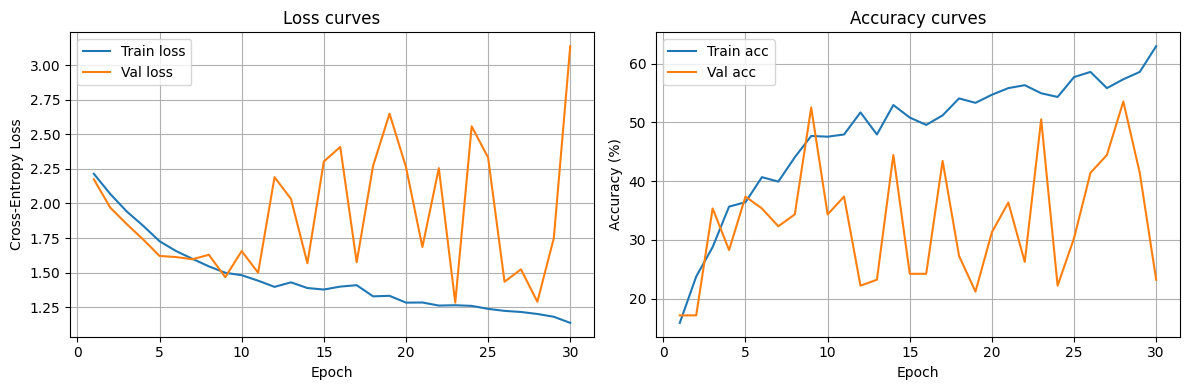

In [ ]:
import matplotlib.pyplot as plt
epochs = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(epochs, train_losses, label="Train loss")
axes[0].plot(epochs, val_losses,   label="Val loss")
axes[0].set_title("Loss curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(epochs, train_accs, label="Train acc")
axes[1].plot(epochs, val_accs,   label="Val acc")
axes[1].set_title("Accuracy curves")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(results_path, "efficient_cnn_curves.png"), dpi=150)
plt.show()

CNN TEST

In [ ]:
def inference(model, dataloader, device):
    model.eval()
    model.to(device)

    correct = 0
    total = 0
    y_true = []
    y_pred = []

    with torch.inference_mode():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            predicted = outputs.argmax(dim=1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    accuracy = 100 * correct / total
    return accuracy, np.array(y_true), np.array(y_pred)

In [ ]:
def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion Matrix", normalize=False):
    """
    Plot confusion matrix for a multiclass classifier.
    """
    if normalize:
        cm = confusion_matrix(y_true, y_pred, normalize="true")
        fmt = ".2f"
        cmap = "Blues"
    else:
        cm = confusion_matrix(y_true, y_pred)
        fmt = "d"
        cmap = "Blues"

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt=fmt,
        cmap=cmap,
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(title)
    plt.tight_layout()
    plt.show()

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))

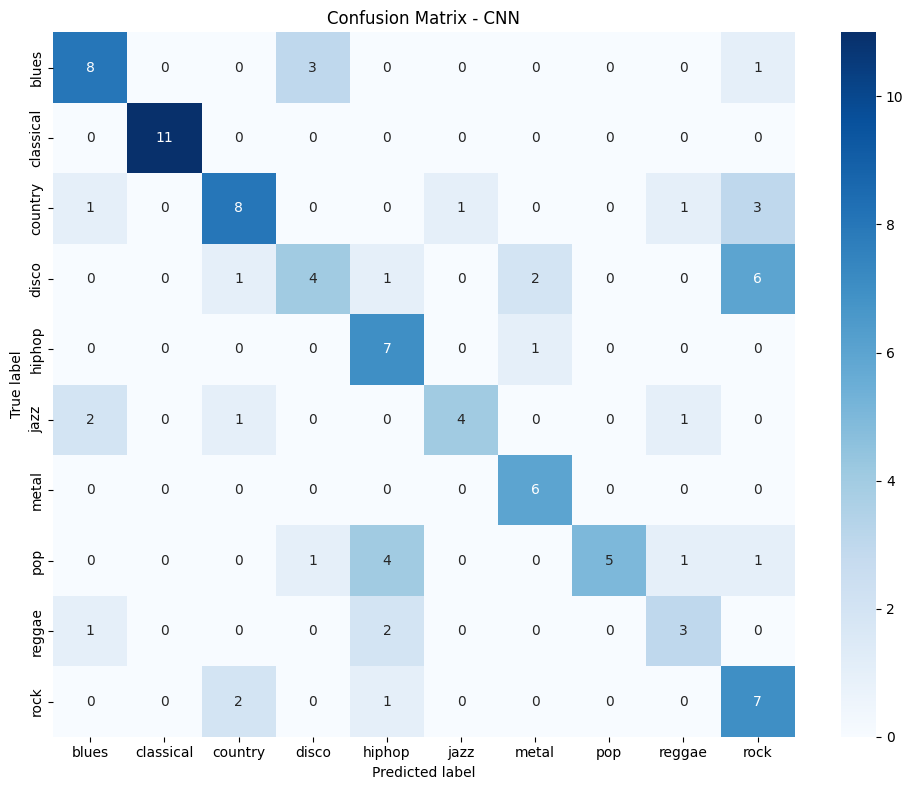


Classification Report:

              precision    recall  f1-score   support

       blues       0.67      0.67      0.67        12
   classical       1.00      1.00      1.00        11
     country       0.67      0.57      0.62        14
       disco       0.50      0.29      0.36        14
      hiphop       0.47      0.88      0.61         8
        jazz       0.80      0.50      0.62         8
       metal       0.67      1.00      0.80         6
         pop       1.00      0.42      0.59        12
      reggae       0.50      0.50      0.50         6
        rock       0.39      0.70      0.50        10

    accuracy                           0.62       101
   macro avg       0.67      0.65      0.63       101
weighted avg       0.68      0.62      0.62       101

Test accuracy: 62.38%


In [ ]:
best_model = CNNGenre(num_classes=10)
best_model.load_state_dict(
    torch.load(os.path.join(results_path, "CNNv1.ckpt"), map_location=device)
)
best_model.to(device)

test_acc, y_true, y_pred = inference(best_model, test_loader, device)
plot_confusion_matrix(
    y_true,
    y_pred,
    class_names=encoder.classes_,
    title="Confusion Matrix - CNN")

print(f"Test accuracy: {test_acc:.2f}%")

TRANSFER LEARNING

PRETRAINED MODEL ResNet18

UNFREEZING ONLY FULLY CONNECTED LAYER

In [ ]:
# RESNET
# DIFFERENT FINE-TUNNING METHODS

num_classes = 10

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)

# TRAINING ONLY LAST LAYER
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

train_losses, train_accs, val_losses, val_accs = train(model, resnet_train_loader, resnet_val_loader, criterion, optimizer, num_epochs=30, model_name='ResNet18.ckpt', device = device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 191MB/s]


Epoch 1
Metrics --> Train Loss: 2.2390 | Train  Acc: 20.2753 | Val Loss: 1.8403 | Val Acc: 30.3030 | Time: 0m 12.80s

Epoch 2
Metrics --> Train Loss: 1.8112 | Train  Acc: 39.1740 | Val Loss: 1.5520 | Val Acc: 52.5253 | Time: 0m 5.50s

Epoch 3
Metrics --> Train Loss: 1.5886 | Train  Acc: 49.6871 | Val Loss: 1.4903 | Val Acc: 50.5051 | Time: 0m 5.62s

Epoch 4
Metrics --> Train Loss: 1.4668 | Train  Acc: 53.3166 | Val Loss: 1.3559 | Val Acc: 58.5859 | Time: 0m 5.14s

Epoch 5
Metrics --> Train Loss: 1.3206 | Train  Acc: 60.0751 | Val Loss: 1.2721 | Val Acc: 57.5758 | Time: 0m 6.07s

Epoch 6
Metrics --> Train Loss: 1.2654 | Train  Acc: 60.3254 | Val Loss: 1.2103 | Val Acc: 62.6263 | Time: 0m 5.13s

Epoch 7
Metrics --> Train Loss: 1.1878 | Train  Acc: 64.5807 | Val Loss: 1.1966 | Val Acc: 63.6364 | Time: 0m 5.66s

Epoch 8
Metrics --> Train Loss: 1.1343 | Train  Acc: 66.2078 | Val Loss: 1.1461 | Val Acc: 60.6061 | Time: 0m 5.51s

Epoch 9
Metrics --> Train Loss: 1.0862 | Train  Acc: 68.7109 | 

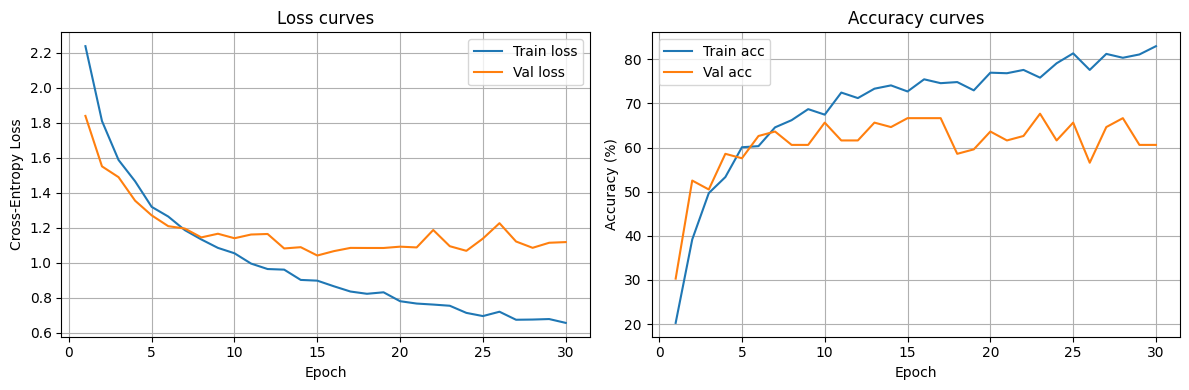

In [ ]:
import matplotlib.pyplot as plt
epochs = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(epochs, train_losses, label="Train loss")
axes[0].plot(epochs, val_losses,   label="Val loss")
axes[0].set_title("Loss curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(epochs, train_accs, label="Train acc")
axes[1].plot(epochs, val_accs,   label="Val acc")
axes[1].set_title("Accuracy curves")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(results_path, "TL_fc.png"), dpi=150)
plt.show()

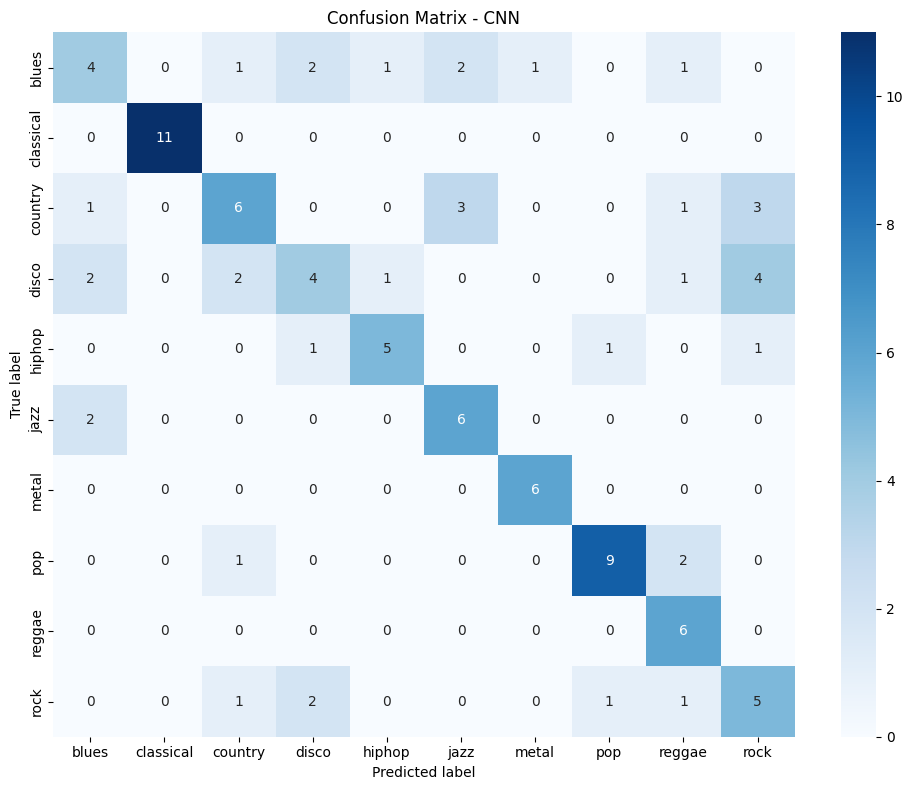


Classification Report:

              precision    recall  f1-score   support

       blues       0.44      0.33      0.38        12
   classical       1.00      1.00      1.00        11
     country       0.55      0.43      0.48        14
       disco       0.44      0.29      0.35        14
      hiphop       0.71      0.62      0.67         8
        jazz       0.55      0.75      0.63         8
       metal       0.86      1.00      0.92         6
         pop       0.82      0.75      0.78        12
      reggae       0.50      1.00      0.67         6
        rock       0.38      0.50      0.43        10

    accuracy                           0.61       101
   macro avg       0.63      0.67      0.63       101
weighted avg       0.61      0.61      0.60       101

Test accuracy: 61.39%


In [ ]:
best_model = models.resnet18(weights=None)
best_model.fc = torch.nn.Linear(best_model.fc.in_features, num_classes)
best_model.load_state_dict(torch.load(os.path.join(results_path, "ResNet18.ckpt"), map_location=device))
best_model.to(device)

test_acc, y_true, y_pred = inference(best_model, resnet_test_loader, device)
plot_confusion_matrix(
    y_true,
    y_pred,
    class_names=encoder.classes_,
    title="Transfer Learning - fc")

print(f"Test accuracy: {test_acc:.2f}%")

TRAINING LAYER 3 + 4

In [ ]:
num_classes = 10

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

# unfreeze layer3, layer4 and fc
for param in model.layer3.parameters():
    param.requires_grad = True
for param in model.layer4.parameters():
    param.requires_grad = True

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam([
    {'params': model.layer3.parameters(), 'lr': 1e-5},
    {'params': model.layer4.parameters(), 'lr': 1e-5},
    {'params': model.fc.parameters(),     'lr': 1e-4},
], weight_decay=1e-4)

train_losses, train_accs, val_losses, val_accs = train(model, resnet_train_loader, resnet_val_loader, criterion, optimizer, num_epochs=30, model_name='ResNet18_L3+L4.ckpt', device=device)

Epoch 1
Metrics --> Train Loss: 2.1900 | Train  Acc: 23.0288 | Val Loss: 1.9527 | Val Acc: 40.4040 | Time: 0m 6.92s

Epoch 2
Metrics --> Train Loss: 1.7071 | Train  Acc: 51.9399 | Val Loss: 1.6419 | Val Acc: 50.5051 | Time: 0m 5.97s

Epoch 3
Metrics --> Train Loss: 1.4256 | Train  Acc: 64.0801 | Val Loss: 1.4338 | Val Acc: 55.5556 | Time: 0m 6.76s

Epoch 4
Metrics --> Train Loss: 1.2286 | Train  Acc: 69.4618 | Val Loss: 1.3116 | Val Acc: 56.5657 | Time: 0m 6.41s

Epoch 5
Metrics --> Train Loss: 1.0677 | Train  Acc: 75.8448 | Val Loss: 1.2130 | Val Acc: 66.6667 | Time: 0m 6.78s

Epoch 6
Metrics --> Train Loss: 0.9197 | Train  Acc: 79.3492 | Val Loss: 1.1632 | Val Acc: 65.6566 | Time: 0m 5.92s

Epoch 7
Metrics --> Train Loss: 0.7958 | Train  Acc: 84.2303 | Val Loss: 1.0937 | Val Acc: 69.6970 | Time: 0m 6.86s

Epoch 8
Metrics --> Train Loss: 0.7015 | Train  Acc: 87.8598 | Val Loss: 1.0514 | Val Acc: 70.7071 | Time: 0m 5.89s

Epoch 9
Metrics --> Train Loss: 0.5953 | Train  Acc: 91.1139 | V

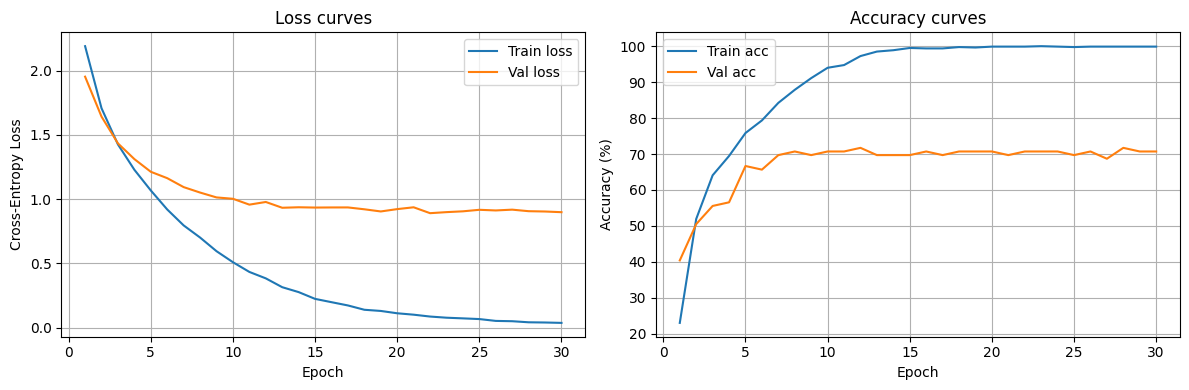

In [ ]:
import matplotlib.pyplot as plt
epochs = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(epochs, train_losses, label="Train loss")
axes[0].plot(epochs, val_losses,   label="Val loss")
axes[0].set_title("Loss curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(epochs, train_accs, label="Train acc")
axes[1].plot(epochs, val_accs,   label="Val acc")
axes[1].set_title("Accuracy curves")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(results_path, "TF_3+4+fc.png"), dpi=150)
plt.show()

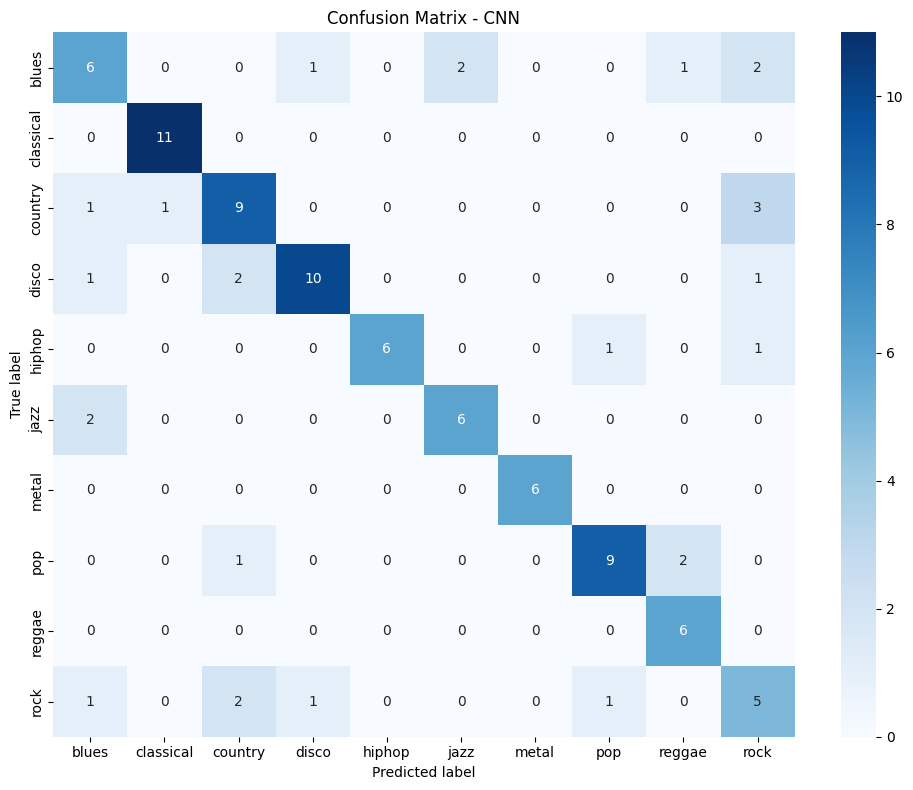


Classification Report:

              precision    recall  f1-score   support

       blues       0.55      0.50      0.52        12
   classical       0.92      1.00      0.96        11
     country       0.64      0.64      0.64        14
       disco       0.83      0.71      0.77        14
      hiphop       1.00      0.75      0.86         8
        jazz       0.75      0.75      0.75         8
       metal       1.00      1.00      1.00         6
         pop       0.82      0.75      0.78        12
      reggae       0.67      1.00      0.80         6
        rock       0.42      0.50      0.45        10

    accuracy                           0.73       101
   macro avg       0.76      0.76      0.75       101
weighted avg       0.75      0.73      0.73       101

Test accuracy (layer3+layer4+fc): 73.27%


In [ ]:
best_model3 = models.resnet18(weights=None)
best_model3.fc = nn.Linear(best_model3.fc.in_features, num_classes)
best_model3.load_state_dict(torch.load(os.path.join(results_path, "ResNet18_L3+L4.ckpt"), map_location=device))
best_model3.to(device)
test_acc, y_true, y_pred = inference(best_model3, resnet_test_loader, device)
plot_confusion_matrix(
    y_true,
    y_pred,
    class_names=encoder.classes_,
    title="Transfer Learning - L3+4+fc")
print(f"Test accuracy (layer3+layer4+fc): {test_acc:.2f}%")

TRAINING LAYER 4 + LAST LAYER

In [ ]:
num_classes = 10

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

# Unfreeze the last residual block (layer4) and the classifier
for param in model.layer4.parameters():
    param.requires_grad = True

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)

for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam([{'params': model.layer4.parameters(), 'lr': 1e-5},{'params': model.fc.parameters(), 'lr': 1e-4}], weight_decay=1e-4)

train_losses, train_accs, val_losses, val_accs = train(model,resnet_train_loader,resnet_val_loader,criterion,optimizer,num_epochs=30,model_name='ResNet18_L4.ckpt',device=device)

Epoch 1
Metrics --> Train Loss: 2.1448 | Train  Acc: 25.1564 | Val Loss: 1.9490 | Val Acc: 37.3737 | Time: 0m 6.13s

Epoch 2
Metrics --> Train Loss: 1.7506 | Train  Acc: 46.8085 | Val Loss: 1.6591 | Val Acc: 50.5051 | Time: 0m 5.60s

Epoch 3
Metrics --> Train Loss: 1.5114 | Train  Acc: 59.4493 | Val Loss: 1.5103 | Val Acc: 55.5556 | Time: 0m 6.53s

Epoch 4
Metrics --> Train Loss: 1.3345 | Train  Acc: 66.2078 | Val Loss: 1.3929 | Val Acc: 58.5859 | Time: 0m 5.56s

Epoch 5
Metrics --> Train Loss: 1.1876 | Train  Acc: 71.2140 | Val Loss: 1.3029 | Val Acc: 59.5960 | Time: 0m 6.47s

Epoch 6
Metrics --> Train Loss: 1.0735 | Train  Acc: 74.9687 | Val Loss: 1.2210 | Val Acc: 61.6162 | Time: 0m 5.58s

Epoch 7
Metrics --> Train Loss: 0.9559 | Train  Acc: 79.4743 | Val Loss: 1.1473 | Val Acc: 63.6364 | Time: 0m 6.52s

Epoch 8
Metrics --> Train Loss: 0.8652 | Train  Acc: 82.6033 | Val Loss: 1.1065 | Val Acc: 65.6566 | Time: 0m 5.52s

Epoch 9
Metrics --> Train Loss: 0.7983 | Train  Acc: 83.4793 | V

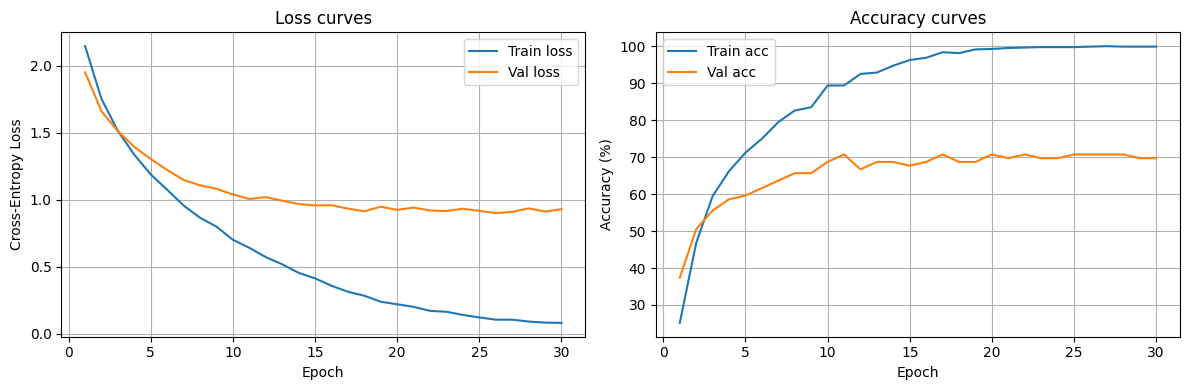

In [ ]:
import matplotlib.pyplot as plt
epochs = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(epochs, train_losses, label="Train loss")
axes[0].plot(epochs, val_losses,   label="Val loss")
axes[0].set_title("Loss curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(epochs, train_accs, label="Train acc")
axes[1].plot(epochs, val_accs,   label="Val acc")
axes[1].set_title("Accuracy curves")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(results_path, "TL_4+fc.png"), dpi=150)
plt.show()

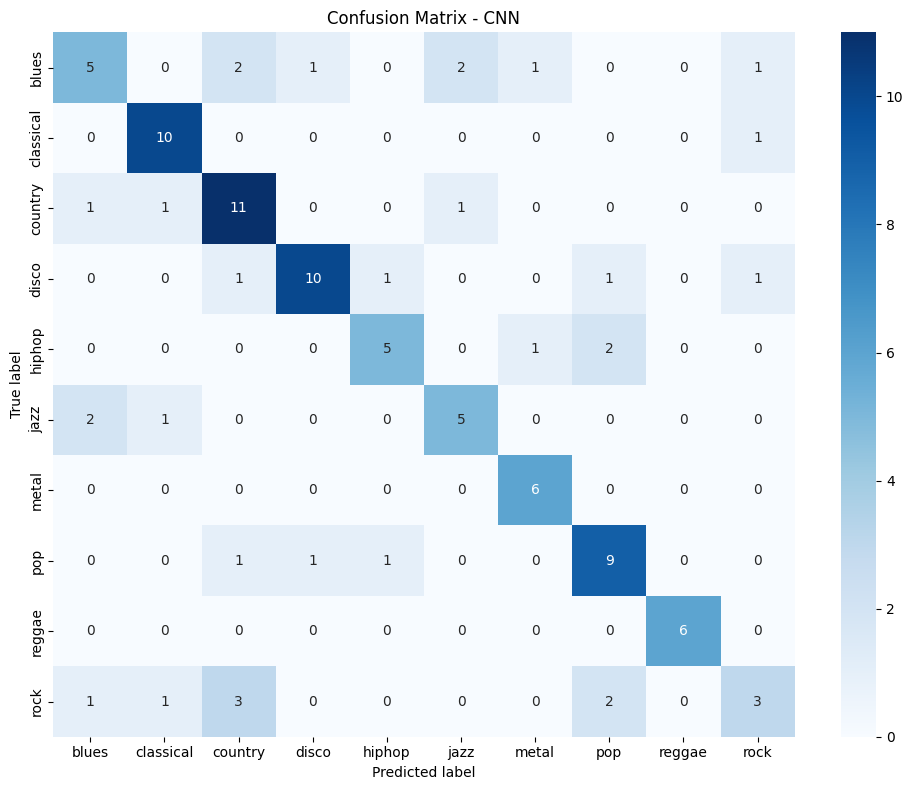


Classification Report:

              precision    recall  f1-score   support

       blues       0.56      0.42      0.48        12
   classical       0.77      0.91      0.83        11
     country       0.61      0.79      0.69        14
       disco       0.83      0.71      0.77        14
      hiphop       0.71      0.62      0.67         8
        jazz       0.62      0.62      0.62         8
       metal       0.75      1.00      0.86         6
         pop       0.64      0.75      0.69        12
      reggae       1.00      1.00      1.00         6
        rock       0.50      0.30      0.38        10

    accuracy                           0.69       101
   macro avg       0.70      0.71      0.70       101
weighted avg       0.69      0.69      0.68       101

Test accuracy (layer4+fc): 69.31%


In [ ]:
best_model2 = models.resnet18(weights=None)
best_model2.fc = nn.Linear(best_model2.fc.in_features, num_classes)
best_model2.load_state_dict(torch.load(os.path.join(results_path, "ResNet18_L4.ckpt"), map_location=device))
best_model2.to(device)
test_acc, y_true, y_pred = inference(best_model2, resnet_test_loader, device)
plot_confusion_matrix(
    y_true,
    y_pred,
    class_names=encoder.classes_,
    title="Transfe Learning L4+fc")

print(f"Test accuracy (layer4+fc): {test_acc:.2f}%")

UNFREEZING LAYER 2, 3, 4 AND FULLY CONNECTED

In [ ]:
num_classes = 10

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

# unfreeze layer3, layer4 and fc
for param in model.layer2.parameters():
    param.requires_grad = True
for param in model.layer3.parameters():
    param.requires_grad = True
for param in model.layer4.parameters():
    param.requires_grad = True

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam([
    {'params': model.layer2.parameters(), 'lr': 1e-5},
    {'params': model.layer3.parameters(), 'lr': 1e-5},
    {'params': model.layer4.parameters(), 'lr': 1e-5},
    {'params': model.fc.parameters(),     'lr': 1e-4},
], weight_decay=1e-4)

train_losses, train_accs, val_losses, val_accs = train(model, resnet_train_loader, resnet_val_loader, criterion, optimizer, num_epochs=30, model_name='ResNet18_L2+L3+L4.ckpt', device=device)

Epoch 1
Metrics --> Train Loss: 2.1559 | Train  Acc: 25.2816 | Val Loss: 2.0528 | Val Acc: 31.3131 | Time: 0m 7.37s

Epoch 2
Metrics --> Train Loss: 1.6870 | Train  Acc: 51.9399 | Val Loss: 1.6770 | Val Acc: 49.4949 | Time: 0m 6.51s

Epoch 3
Metrics --> Train Loss: 1.4092 | Train  Acc: 64.3304 | Val Loss: 1.4856 | Val Acc: 51.5152 | Time: 0m 7.39s

Epoch 4
Metrics --> Train Loss: 1.1995 | Train  Acc: 72.2153 | Val Loss: 1.3500 | Val Acc: 62.6263 | Time: 0m 6.38s

Epoch 5
Metrics --> Train Loss: 1.0337 | Train  Acc: 75.8448 | Val Loss: 1.2373 | Val Acc: 61.6162 | Time: 0m 7.86s

Epoch 6
Metrics --> Train Loss: 0.8876 | Train  Acc: 82.7284 | Val Loss: 1.1654 | Val Acc: 61.6162 | Time: 0m 6.42s

Epoch 7
Metrics --> Train Loss: 0.7557 | Train  Acc: 85.7322 | Val Loss: 1.1206 | Val Acc: 61.6162 | Time: 0m 7.30s

Epoch 8
Metrics --> Train Loss: 0.6449 | Train  Acc: 89.3617 | Val Loss: 1.0443 | Val Acc: 63.6364 | Time: 0m 6.47s

Epoch 9
Metrics --> Train Loss: 0.5343 | Train  Acc: 93.1164 | V

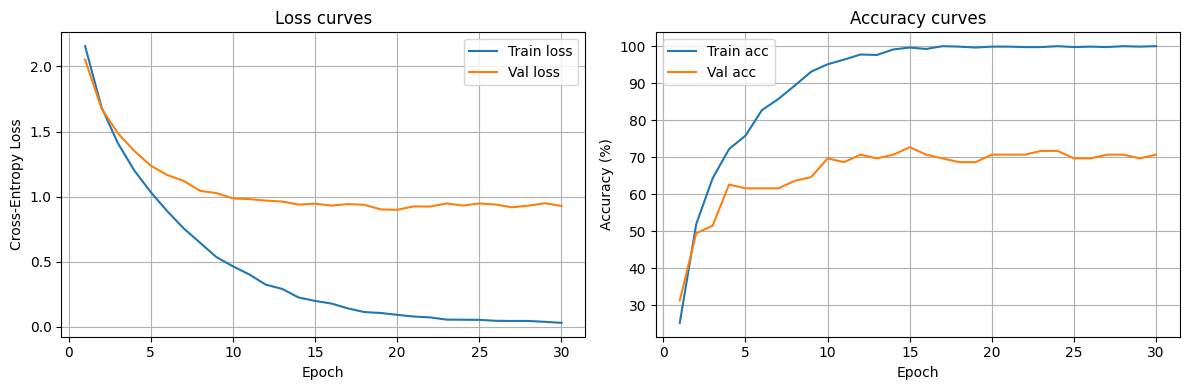

In [ ]:
import matplotlib.pyplot as plt
epochs = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(epochs, train_losses, label="Train loss")
axes[0].plot(epochs, val_losses,   label="Val loss")
axes[0].set_title("Loss curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(epochs, train_accs, label="Train acc")
axes[1].plot(epochs, val_accs,   label="Val acc")
axes[1].set_title("Accuracy curves")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(results_path, "TF_2+3+4+fc.png"), dpi=150)
plt.show()

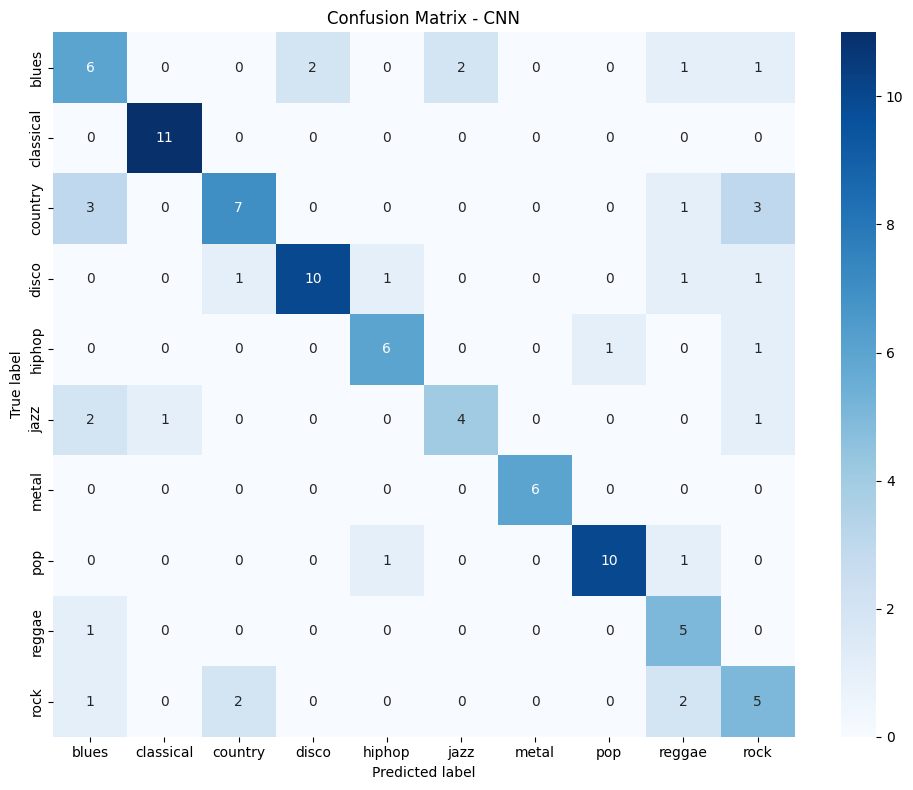


Classification Report:

              precision    recall  f1-score   support

       blues       0.46      0.50      0.48        12
   classical       0.92      1.00      0.96        11
     country       0.70      0.50      0.58        14
       disco       0.83      0.71      0.77        14
      hiphop       0.75      0.75      0.75         8
        jazz       0.67      0.50      0.57         8
       metal       1.00      1.00      1.00         6
         pop       0.91      0.83      0.87        12
      reggae       0.45      0.83      0.59         6
        rock       0.42      0.50      0.45        10

    accuracy                           0.69       101
   macro avg       0.71      0.71      0.70       101
weighted avg       0.72      0.69      0.70       101

Test accuracy (layer2+3+4+fc): 69.31%


In [ ]:
best_model4 = models.resnet18(weights=None)
best_model4.fc = nn.Linear(best_model4.fc.in_features, num_classes)
best_model4.load_state_dict(torch.load(os.path.join(results_path, "ResNet18_L2+L3+L4.ckpt"), map_location=device))
best_model4.to(device)
test_acc, y_true, y_pred = inference(best_model4, resnet_test_loader, device)
plot_confusion_matrix(
    y_true,
    y_pred,
    class_names=encoder.classes_,
    title="Transfer Learning - 2+3+4+fc")
print(f"Test accuracy (layer2+3+4+fc): {test_acc:.2f}%")